# Customer Churn Prediction

## Problem Statement

The goal of this project is to build a machine learning model that predicts whether a customer is likely to churn (leave the company's service) based on demographic, account, and service-related information.

This project follows an end-to-end machine learning workflow including data preprocessing, exploratory data analysis (EDA), feature engineering, model building, hyperparameter tuning, evaluation, and deployment using Streamlit.

## Import Libraries

Import the required libraries for data manipulation, visualization, machine learning, and model evaluation.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Settings
plt.style.use("seaborn-v0_8")

## Load Dataset

Load the customer churn dataset into a Pandas DataFrame for analysis and preprocessing.

In [2]:
df = pd.read_csv("customer_churn.csv")

## Dataset Overview

Understand the structure, size, and basic information of the dataset before performing data preprocessing and analysis.

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [9]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

Explore the dataset to understand the distribution of features, identify patterns, detect anomalies, and gain insights before data preprocessing and model building.

### Target Variable Analysis

Analyze the target variable to understand the class distribution and identify whether the dataset is balanced or imbalanced.

In [10]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

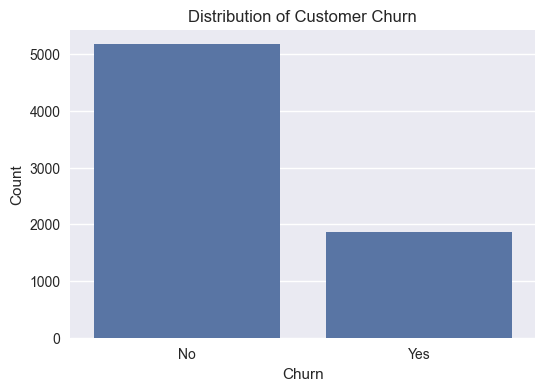

In [11]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Churn", data=df)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

### Categorical Feature Analysis

Analyze categorical features to understand the distribution of categories and identify useful patterns before preprocessing.

In [12]:
df.select_dtypes(include="object").columns

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [13]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [14]:
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [15]:
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


**Observation:**

The `TotalCharges` column is stored as an object instead of a numeric data type. This issue will be addressed during the Data Cleaning phase.

In [16]:
len(df.select_dtypes(include="object").columns)

18

In [17]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

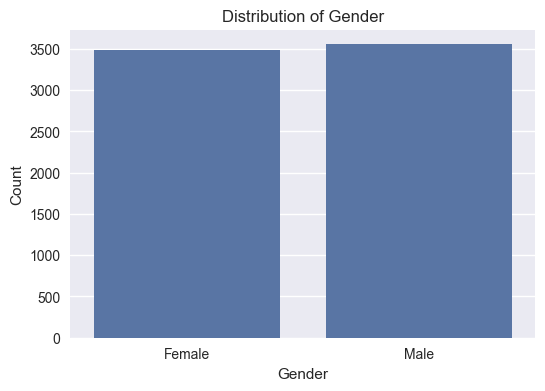

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title("Distribution of Gender")
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

**Observation:**

- The dataset contains almost an equal number of male and female customers.
- The `gender` feature appears to be well balanced.
- There is no significant class imbalance in this feature.

In [19]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

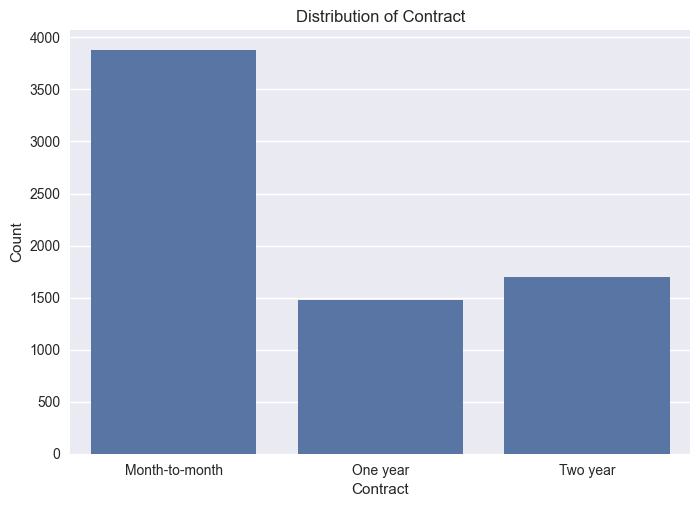

In [20]:

sns.countplot(x='Contract', data=df)

plt.title("Distribution of Contract")
plt.xlabel('Contract')
plt.ylabel('Count')

plt.show()

**Observation:**

- Most customers are on a **Month-to-month** contract.
- **One year** contract has the lowest number of customers.
- The contract distribution is imbalanced, with Month-to-month being the dominant contract type.

In [21]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

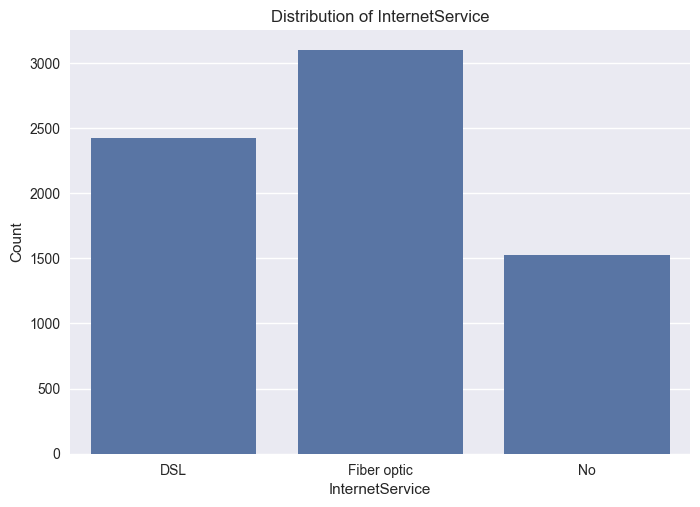

In [22]:
sns.countplot(x='InternetService', data=df)

plt.title("Distribution of InternetService")
plt.xlabel('InternetService')
plt.ylabel('Count')

plt.show()

**Observation:**

- Most customers use **Fiber optic** internet service.
- **DSL** is the second most common internet service.
- A smaller number of customers do not use any internet service.
- The distribution of internet service types is not balanced.

### Bivariate Analysis

Analyze the relationship between input features and the target variable (`Churn`) to identify patterns that may influence customer churn.

##### Contract vs Churn


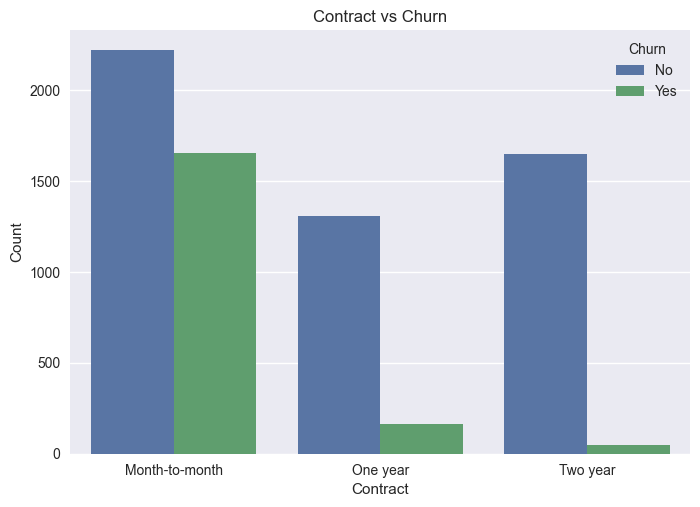

In [23]:
sns.countplot(x='Contract',hue='Churn', data=df)

plt.title("Contract vs Churn")
plt.xlabel('Contract')
plt.ylabel('Count')

plt.show()

**Observation:**

- Customers with **Month-to-month** contracts show the highest number of churn cases.
- Customers with **One year** and especially **Two year** contracts have significantly fewer churn cases.
- This indicates that customers with long-term contracts are more likely to remain with the company.
- The **Contract** feature appears to have a strong relationship with customer churn.

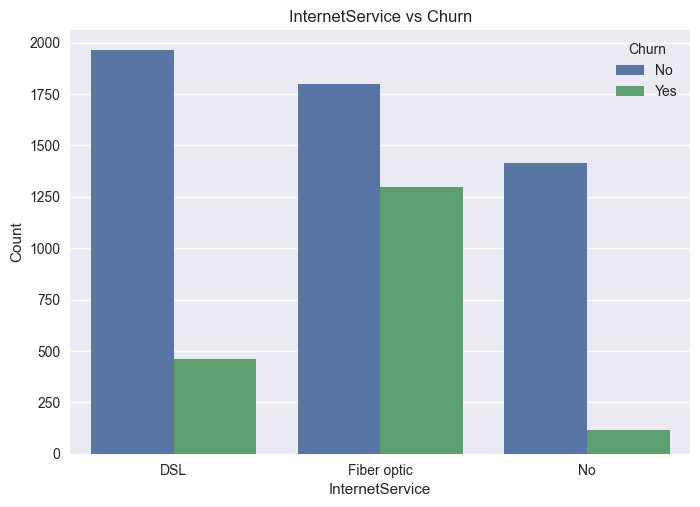

In [24]:
sns.countplot(x='InternetService',hue='Churn', data=df)

plt.title("InternetService vs Churn")
plt.xlabel('InternetService')
plt.ylabel('Count')

plt.show()

**Observation:**

- Customers using **Fiber optic** internet service show a higher number of churn cases.
- Customers with **DSL** have comparatively fewer churn cases.
- Customers with **No Internet Service** have the lowest number of churn cases.
- The **InternetService** feature appears to have a relationship with customer churn.

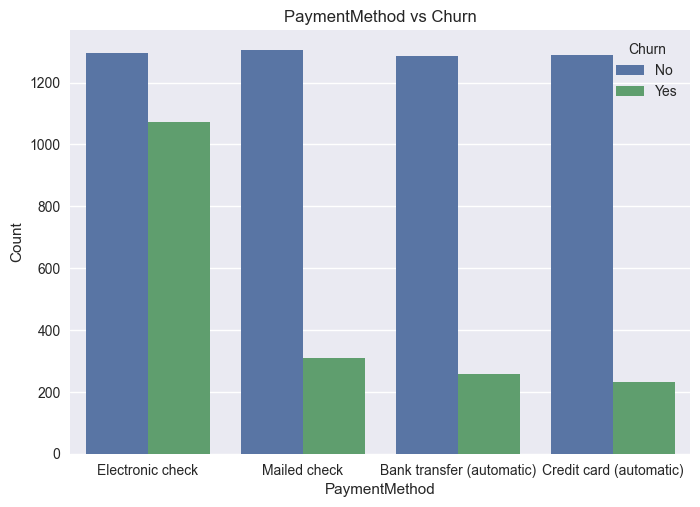

In [25]:
sns.countplot(x='PaymentMethod',hue='Churn', data=df)

plt.title("PaymentMethod vs Churn")
plt.xlabel('PaymentMethod')
plt.ylabel('Count')

plt.show()

**Observation:**

- Customers using **Electronic check** show the highest number of churn cases.
- Customers using automatic payment methods have comparatively fewer churn cases.
- The **PaymentMethod** feature may influence customer churn.

## Data Cleaning

Clean the dataset by handling invalid values, correcting data types, and preparing the data for machine learning.

In [26]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [27]:
df["TotalCharges"].isna().sum()

np.int64(11)

#### Handle Missing Values

The `TotalCharges` column contained 11 missing values after replacing blank spaces with `NaN`. Since these represent only a very small portion of the dataset (11 out of 7043 rows), they will be removed to maintain data quality.

In [28]:
df = df.dropna()

In [29]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [30]:
df.shape

(7032, 21)

In [31]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [32]:
df["TotalCharges"].dtype

dtype('float64')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

### Numerical Feature Analysis

Analyze the distribution of numerical features and identify potential outliers before model training.

In [34]:
df.select_dtypes(include=["int64", "float64"]).columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

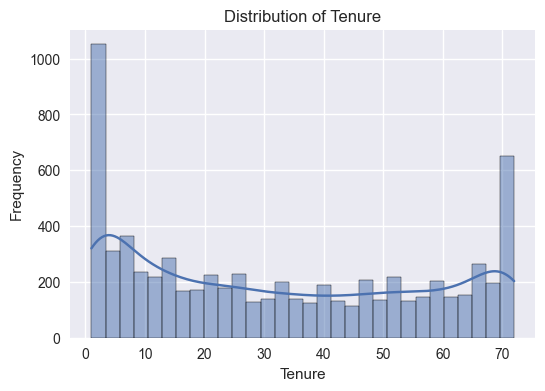

In [35]:
plt.figure(figsize=(6,4))

sns.histplot(df["tenure"], bins=30, kde=True)

plt.title("Distribution of Tenure")
plt.xlabel("Tenure")
plt.ylabel("Frequency")

plt.show()

**Observation:**

- A large number of customers have very low tenure.
- Another noticeable group of customers has high tenure, indicating many long-term customers.
- The tenure distribution is not normally distributed.

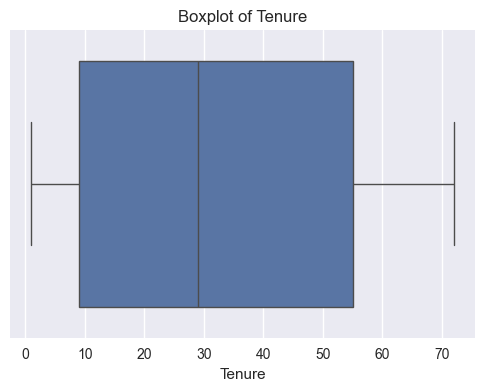

In [36]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["tenure"])

plt.title("Boxplot of Tenure")
plt.xlabel("Tenure")

plt.show()

**Observation:**

- No significant outliers are observed in the `tenure` feature.
- Most customers fall within the expected tenure range.
- The feature appears to have a reasonable spread without extreme values.

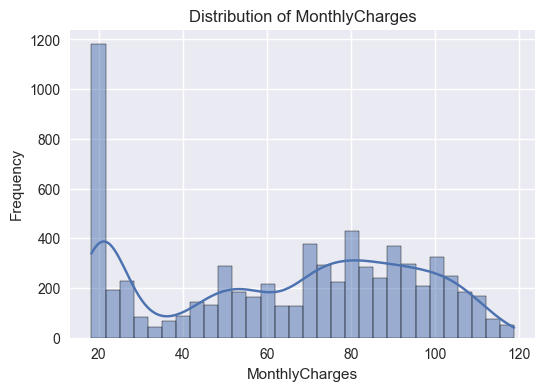

In [37]:
plt.figure(figsize=(6,4))

sns.histplot(df["MonthlyCharges"], bins=30, kde=True)

plt.title("Distribution of MonthlyCharges")
plt.xlabel("MonthlyCharges")
plt.ylabel("Frequency")

plt.show()

**Observation:**

- Monthly charges are spread across different price ranges.
- The distribution is not perfectly uniform and shows multiple peaks.
- This indicates that customers are subscribed to different pricing plans.

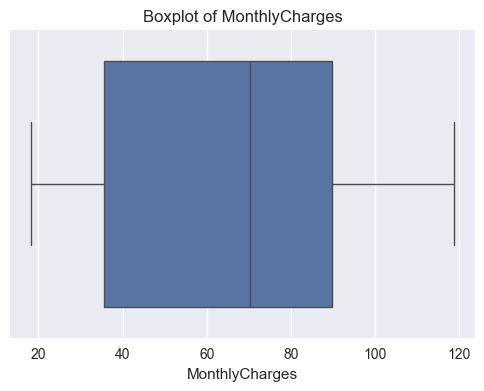

In [38]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["MonthlyCharges"])

plt.title("Boxplot of MonthlyCharges")
plt.xlabel("MonthlyCharges")

plt.show()

**Observation:**

- No significant outliers are observed in the `MonthlyCharges` feature.
- The values are within an acceptable range.
- No outlier treatment is required for this feature.

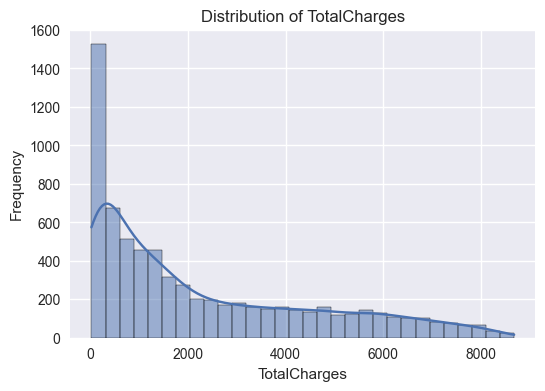

In [39]:
plt.figure(figsize=(6,4))

sns.histplot(df["TotalCharges"], bins=30, kde=True)

plt.title("Distribution of TotalCharges")
plt.xlabel("TotalCharges")
plt.ylabel("Frequency")

plt.show()

**Observation:**

- The `TotalCharges` feature is right-skewed, with most customers having lower total charges.
- The frequency of customers decreases as total charges increase.
- A smaller number of customers have very high total charges, representing long-term customers or customers with higher monthly plans.

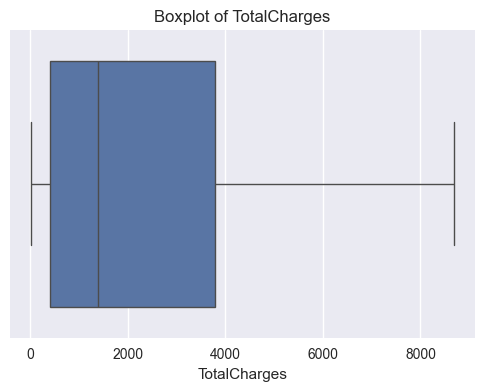

In [40]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["TotalCharges"])

plt.title("Boxplot of TotalCharges")
plt.xlabel("TotalCharges")

plt.show()

**Observation:**

- No significant outliers are observed in the `TotalCharges` feature.
- The feature shows variation in customer total spending.
- The spread indicates that customers have different levels of total charges based on their tenure and service usage.

## Correlation Analysis

Analyze the relationship between numerical features to understand how strongly they are correlated with each other.

In [41]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


**Observation:**

- `tenure` and `TotalCharges` show a strong positive correlation (0.83), indicating that customers with longer tenure generally accumulate higher total charges.
- `MonthlyCharges` and `TotalCharges` have a moderate positive correlation (0.65), suggesting that higher monthly charges contribute to higher total charges.
- `SeniorCitizen` has a weak correlation with the other numerical features, indicating little linear relationship.

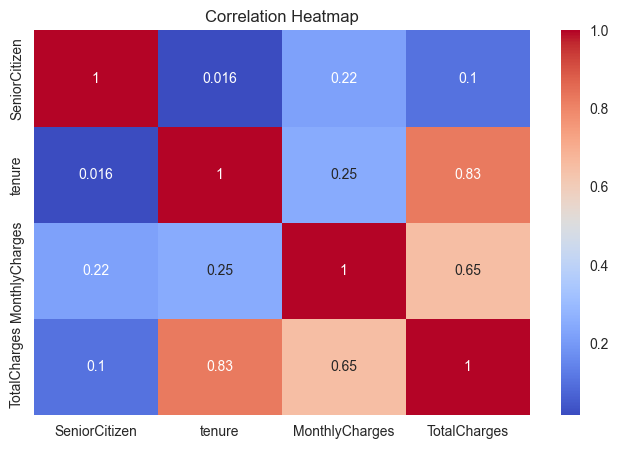

In [42]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

**Observation:**

- The heatmap shows a strong positive correlation between `tenure` and `TotalCharges`.
- `MonthlyCharges` and `TotalCharges` have a moderate positive correlation.
- `MonthlyCharges` and `tenure` show a weak positive correlation.
- `SeniorCitizen` has a weak correlation with the other numerical features.
- No strong negative correlations are observed among the numerical features.

## Data Preprocessing

Prepare the dataset for machine learning by selecting features, separating the target variable, and applying the necessary preprocessing techniques.

### Drop Unnecessary Columns

The `customerID` column is a unique identifier and does not provide useful information for predicting customer churn. Therefore, it is removed before model training.

In [43]:
df = df.drop("customerID", axis=1)

In [44]:
df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


### Separate Features and Target Variable

The dataset is divided into input features (`X`) and the target variable (`y`) before training the machine learning model.

In [45]:
X = df.drop('Churn', axis=1)
y = df["Churn"]

In [46]:
print(X.shape)
print(y.shape)

(7032, 19)
(7032,)


### Train-Test Split

Split the dataset into training and testing sets to evaluate the model on unseen data. The model is trained using the training set and evaluated using the testing set to measure its generalization performance.

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [48]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(5625, 19)
(1407, 19)
(5625,)
(1407,)


### Identify Numerical and Categorical Features

Separate the input features into numerical and categorical columns so that appropriate preprocessing techniques can be applied using a Column Transformer.

In [49]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns

numerical_columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [50]:
categorical_columns = X.select_dtypes(include="object").columns

categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [51]:
print(len(numerical_columns))

print(len(categorical_columns))

4
15


### Create a Column Transformer

Apply appropriate preprocessing techniques to numerical and categorical features using a Column Transformer. Numerical features are scaled using `StandardScaler`, while categorical features are encoded using `OneHotEncoder`.

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [53]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

In [54]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


### Build a Machine Learning Pipeline

Create a machine learning pipeline that combines preprocessing and model training into a single workflow. This ensures that all preprocessing steps are applied consistently during both training and prediction.

## Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification tasks. It estimates the probability of a customer belonging to a particular class using the logistic (sigmoid) function. In this project, Logistic Regression is used as the baseline model to predict whether a customer is likely to churn or not.

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [56]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression())
])

In [57]:
lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [58]:
lr_y_pred = lr_pipeline.predict(X_test)

## Model Evaluation

Evaluate the performance of the Logistic Regression model using classification metrics to measure its predictive performance on the test dataset.

In [59]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Accuracy Score
lr_acc_score = accuracy_score(y_test,lr_y_pred)
print("Accracy score:", lr_acc_score ,'\n')

# Confusion matrix
lr_conf_mat = confusion_matrix(y_test,lr_y_pred)
print("Confusion matrix:\n", lr_conf_mat,'\n')

# Classification report
lr_cls_repo = classification_report(y_test,lr_y_pred, output_dict=True)
print("Classification report:\n",lr_cls_repo)

Accracy score: 0.8038379530916845 

Confusion matrix:
 [[917 116]
 [160 214]] 

Classification report:
 {'No': {'precision': 0.851439182915506, 'recall': 0.8877057115198451, 'f1-score': 0.8691943127962085, 'support': 1033.0}, 'Yes': {'precision': 0.6484848484848484, 'recall': 0.5721925133689839, 'f1-score': 0.6079545454545454, 'support': 374.0}, 'accuracy': 0.8038379530916845, 'macro avg': {'precision': 0.7499620157001772, 'recall': 0.7299491124444145, 'f1-score': 0.738574429125377, 'support': 1407.0}, 'weighted avg': {'precision': 0.7974911224485083, 'recall': 0.8038379530916845, 'f1-score': 0.7997531806101517, 'support': 1407.0}}


### Observation

- The Logistic Regression model achieved an **accuracy of 80.38%** on the test dataset.
- The model performed well in predicting customers who did not churn, achieving high precision and recall for the **No** class.
- For the **Yes (Churn)** class, the model achieved a **precision of 65%** and a **recall of 57%**, indicating that a considerable number of customers who actually churned were not identified.
- Overall, Logistic Regression provides a strong **baseline model** with good overall performance, but its ability to detect churned customers can be further improved using more advanced machine learning models such as Decision Tree, Random Forest, or XGBoost.

## Decision Tree Classifier

Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It works by recursively splitting the dataset into smaller subsets based on feature values, creating a tree-like structure of decision rules. In this project, the Decision Tree Classifier is used to classify whether a customer is likely to churn or not.

In [60]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier())
])

In [61]:
dt_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [62]:
dt_y_pred = dt_pipeline.predict(X_test)

## Model Evaluation

The performance of the Decision Tree Classifier is evaluated using classification metrics such as Accuracy, Confusion Matrix, and Classification Report. These metrics provide insights into the model's predictive performance and help compare it with the baseline Logistic Regression model.

In [63]:

# Accuracy Score
dt_acc_score = accuracy_score(y_test,dt_y_pred)
print("Accracy score:", dt_acc_score ,'\n')

# Confusion matrix
dt_conf_mat = confusion_matrix(y_test,dt_y_pred)
print("Confusion matrix:\n", dt_conf_mat,'\n')

# Classification report
dt_cls_repo = classification_report(y_test,dt_y_pred, output_dict=True)
print("Classification report:\n",dt_cls_repo)

Accracy score: 0.7228144989339019 

Confusion matrix:
 [[824 209]
 [181 193]] 

Classification report:
 {'No': {'precision': 0.8199004975124378, 'recall': 0.797676669893514, 'f1-score': 0.8086359175662414, 'support': 1033.0}, 'Yes': {'precision': 0.48009950248756217, 'recall': 0.516042780748663, 'f1-score': 0.49742268041237114, 'support': 374.0}, 'accuracy': 0.7228144989339019, 'macro avg': {'precision': 0.6499999999999999, 'recall': 0.6568597253210886, 'f1-score': 0.6530292989893063, 'support': 1407.0}, 'weighted avg': {'precision': 0.7295767077901183, 'recall': 0.7228144989339019, 'f1-score': 0.7259111480598112, 'support': 1407.0}}


### Observation

- The Decision Tree Classifier achieved an **accuracy of 73.56%** on the test dataset.
- The model showed lower performance in predicting both churn and non-churn customers compared to the baseline Logistic Regression model.
- For the **Yes (Churn)** class, the model achieved a **precision of 50%** and a **recall of 51%**, indicating that it struggled to correctly identify customers who actually churned.
- Overall, the Decision Tree Classifier underperformed compared to Logistic Regression, suggesting that the model may have overfitted the training data. Further improvement can be achieved through hyperparameter tuning or by using ensemble methods such as Random Forest.

## Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple Decision Trees to improve predictive performance and reduce overfitting. Each tree is trained on a random subset of the data, and the final prediction is made using majority voting. In this project, the Random Forest Classifier is used to predict whether a customer is likely to churn or not.

In [64]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [65]:
rf_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
rf_y_pred = rf_pipeline.predict(X_test)

## Model Evaluation

The performance of the Random Forest Classifier is evaluated using Accuracy, Confusion Matrix, and Classification Report. These evaluation metrics help measure the model's predictive performance and compare it with previously trained models.

In [67]:
# Accuracy Score
rf_acc_score = accuracy_score(y_test, rf_y_pred)
print("Accracy score:", rf_acc_score ,'\n')

# Confusion matrix
rf_conf_mat = confusion_matrix(y_test, rf_y_pred)
print("Confusion matrix:\n", rf_conf_mat,'\n')

# Classification report
rf_cls_repo = classification_report(y_test, rf_y_pred, output_dict=True)
print("Classification report:\n", rf_cls_repo)

Accracy score: 0.7874911158493249 

Confusion matrix:
 [[927 106]
 [193 181]] 

Classification report:
 {'No': {'precision': 0.8276785714285714, 'recall': 0.8973862536302033, 'f1-score': 0.8611240130051091, 'support': 1033.0}, 'Yes': {'precision': 0.6306620209059234, 'recall': 0.4839572192513369, 'f1-score': 0.5476550680786687, 'support': 374.0}, 'accuracy': 0.7874911158493249, 'macro avg': {'precision': 0.7291702961672474, 'recall': 0.6906717364407701, 'f1-score': 0.704389540541889, 'support': 1407.0}, 'weighted avg': {'precision': 0.7753088557956854, 'recall': 0.7874911158493249, 'f1-score': 0.7777996452705755, 'support': 1407.0}}


### Observation

- The Random Forest Classifier achieved an **accuracy of 78.75%** on the test dataset.
- The model performed well in predicting customers who did not churn, achieving a **precision of 83%** and a **recall of 90%** for the **No** class.
- For the **Yes (Churn)** class, the model achieved a **precision of 63%** and a **recall of 48%**, indicating that it still missed a considerable number of customers who actually churned.
- Overall, the Random Forest Classifier performed better than the Decision Tree Classifier but did not outperform the baseline Logistic Regression model. Hyperparameter tuning may further improve its predictive performance.

## K-Nearest Neighbors (KNN) Classifier

K-Nearest Neighbors is a supervised machine learning algorithm used for classification and regression tasks. It classifies data points based on the similarity or distance between them and their nearest neighbors. In this project, KNN Classifier is used to predict whether a customer is likely to churn or not.

In [68]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

In [69]:
knn_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
knn_y_pred = knn_pipeline.predict(X_test)

## Model Evaluation

The performance of the K-Nearest Neighbors Classifier is evaluated using Accuracy, Confusion Matrix, and Classification Report. These evaluation metrics help measure the model's ability to correctly classify churn and non-churn customers and compare its performance with previously evaluated models.

In [76]:
# Accuracy Score
knn_acc_score = accuracy_score(y_test, knn_y_pred)
print("Accracy score:", knn_acc_score ,'\n')

# Confusion matrix
knn_conf_mat = confusion_matrix(y_test, knn_y_pred)
print("Confusion matrix:\n", knn_conf_mat,'\n')

# Classification report
knn_cls_repo = classification_report(y_test, knn_y_pred, output_dict=True)
print("Classification report:\n", knn_cls_repo)

Accracy score: 0.7611940298507462 

Confusion matrix:
 [[854 179]
 [157 217]] 

Classification report:
 {'No': {'precision': 0.8447082096933729, 'recall': 0.8267182962245886, 'f1-score': 0.8356164383561644, 'support': 1033.0}, 'Yes': {'precision': 0.547979797979798, 'recall': 0.5802139037433155, 'f1-score': 0.5636363636363636, 'support': 374.0}, 'accuracy': 0.7611940298507462, 'macro avg': {'precision': 0.6963440038365855, 'recall': 0.703466099983952, 'f1-score': 0.699626400996264, 'support': 1407.0}, 'weighted avg': {'precision': 0.76583370650867, 'recall': 0.7611940298507462, 'f1-score': 0.7633203843794726, 'support': 1407.0}}


### Observation

- The K-Nearest Neighbors (KNN) Classifier achieved an **accuracy of 76.12%** on the test dataset.
- The model performed well in predicting customers who did not churn, achieving a **precision of 84%** and a **recall of 83%** for the **No** class.
- For the **Yes (Churn)** class, the model achieved a **precision of 55%** and a **recall of 58%**, indicating that it was able to identify slightly more churn customers compared to some previous models but still missed a considerable number of actual churn cases.
- Overall, KNN provided reasonable performance but did not outperform Logistic Regression, which achieved better overall accuracy and churn prediction performance. Further improvements can be explored using hyperparameter tuning and more advanced ensemble models.

## Support Vector Machine (SVM) Classifier

Support Vector Machine is a supervised machine learning algorithm used for classification tasks. It finds the optimal decision boundary (hyperplane) that separates different classes by maximizing the margin between data points. In this project, SVM Classifier is used to predict whether a customer is likely to churn or not.

In [77]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC())
])

In [78]:
svm_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
svm_y_pred = svm_pipeline.predict(X_test)

## Model Evaluation

The performance of the Support Vector Machine Classifier is evaluated using Accuracy, Confusion Matrix, and Classification Report. These evaluation metrics help analyze the model's ability to classify churn and non-churn customers and compare its performance with other trained models.

In [80]:
# Accuracy Score
svm_acc_score = accuracy_score(y_test, svm_y_pred)
print("Accracy score:", svm_acc_score ,'\n')

# Confusion matrix
svm_conf_mat = confusion_matrix(y_test, svm_y_pred)
print("Confusion matrix:\n", svm_conf_mat,'\n')

# Classification report
svm_cls_repo = classification_report(y_test, svm_y_pred, output_dict=True)
print("Classification report:\n", svm_cls_repo)

Accracy score: 0.7917555081734187 

Confusion matrix:
 [[929 104]
 [189 185]] 

Classification report:
 {'No': {'precision': 0.830948121645796, 'recall': 0.8993223620522749, 'f1-score': 0.8637842863784286, 'support': 1033.0}, 'Yes': {'precision': 0.6401384083044983, 'recall': 0.4946524064171123, 'f1-score': 0.5580693815987934, 'support': 374.0}, 'accuracy': 0.7917555081734187, 'macro avg': {'precision': 0.7355432649751472, 'recall': 0.6969873842346936, 'f1-score': 0.710926833988611, 'support': 1407.0}, 'weighted avg': {'precision': 0.780228268916837, 'recall': 0.7917555081734187, 'f1-score': 0.7825210494291865, 'support': 1407.0}}


### Observation

- The Support Vector Machine (SVM) Classifier achieved an **accuracy of 79.18%** on the test dataset.
- The model performed well in predicting customers who did not churn, achieving a **precision of 83%** and a **recall of 90%** for the **No** class.
- For the **Yes (Churn)** class, the model achieved a **precision of 64%** and a **recall of 49%**, indicating that the model was able to correctly identify some churn customers but still missed a significant number of actual churn cases.
- Overall, SVM provided good overall performance but did not outperform the Logistic Regression model. The model may achieve better results through hyperparameter tuning and optimization of parameters such as kernel and regularization.

## XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an advanced ensemble machine learning algorithm based on decision trees. It builds multiple trees sequentially, where each new tree focuses on correcting the errors made by previous trees. In this project, XGBoost Classifier is used to predict whether a customer is likely to churn or not.

In [81]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(random_state=42))
])

#### Target Encoding for XGBoost

XGBoost requires numerical target labels for classification. Therefore, churn labels are converted from categorical values (`No`, `Yes`) into numerical values (`0`, `1`) before training the model.

In [82]:
y_train_xgb = y_train.replace({'No': 0, 'Yes': 1})
y_test_xgb = y_test.replace({'No': 0, 'Yes': 1})

In [83]:
xgb_pipeline.fit(X_train,y_train_xgb)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [84]:
xgb_y_pred = xgb_pipeline.predict(X_test)

## Model Evaluation

The performance of the XGBoost Classifier is evaluated using Accuracy, Confusion Matrix, and Classification Report. These evaluation metrics help analyze the model's ability to correctly classify churn and non-churn customers and compare its performance with previously trained models.

In [85]:
# Accuracy Score
xgb_acc_score = accuracy_score(y_test_xgb, xgb_y_pred)
print("Accracy score:", xgb_acc_score ,'\n')

# Confusion matrix
xgb_conf_mat = confusion_matrix(y_test_xgb, xgb_y_pred)
print("Confusion matrix:\n", xgb_conf_mat,'\n')

# Classification report
xgb_cls_repo = classification_report(y_test_xgb, xgb_y_pred, output_dict=True)
print("Classification report:\n", xgb_cls_repo)

Accracy score: 0.7690120824449183 

Confusion matrix:
 [[885 148]
 [177 197]] 

Classification report:
 {'0': {'precision': 0.8333333333333334, 'recall': 0.856727976766699, 'f1-score': 0.8448687350835322, 'support': 1033.0}, '1': {'precision': 0.5710144927536231, 'recall': 0.5267379679144385, 'f1-score': 0.5479833101529903, 'support': 374.0}, 'accuracy': 0.7690120824449183, 'macro avg': {'precision': 0.7021739130434783, 'recall': 0.6917329723405687, 'f1-score': 0.6964260226182613, 'support': 1407.0}, 'weighted avg': {'precision': 0.7636053686021239, 'recall': 0.7690120824449183, 'f1-score': 0.7659524956208296, 'support': 1407.0}}


### Observation

- The XGBoost Classifier achieved an **accuracy of 76.90%** on the test dataset.
- The model performed well in predicting customers who did not churn, achieving a **precision of 83%** and a **recall of 86%** for the **No** class.
- For the **Yes (Churn)** class, the model achieved a **precision of 57%** and a **recall of 53%**, indicating that the model still missed a significant number of customers who actually churned.
- Overall, XGBoost provided reasonable performance but did not outperform the baseline Logistic Regression model. Further improvement can be achieved through **hyperparameter tuning** and optimizing model parameters to improve churn prediction performance.

## Model Comparison

After training multiple machine learning models, their performance is compared using evaluation metrics such as Accuracy, Precision, Recall, and F1-score. This comparison helps identify the best-performing model for predicting customer churn.

In [86]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "XGBoost"
    ],
    "Accuracy": [
        lr_acc_score,
        dt_acc_score,
        rf_acc_score,
        knn_acc_score,
        svm_acc_score,
        xgb_acc_score
    ],
    "Precision (Yes)": [
        lr_cls_repo['Yes']['precision'],
        dt_cls_repo['Yes']['precision'],
        rf_cls_repo['Yes']['precision'],
        knn_cls_repo['Yes']['precision'],
        svm_cls_repo['Yes']['precision'],
        xgb_cls_repo['1']['precision']
    ],
    "Recall (Yes)": [
        lr_cls_repo['Yes']['recall'],
        dt_cls_repo['Yes']['recall'],
        rf_cls_repo['Yes']['recall'],
        knn_cls_repo['Yes']['recall'],
        svm_cls_repo['Yes']['recall'],
        xgb_cls_repo['1']['recall']
    ]
})

model_comparison

,Model,Accuracy,Precision (Yes),Recall (Yes)
0,Logistic Regression,0.803838,0.648485,0.572193
1,Decision Tree,0.722814,0.480100,0.516043
2,Random Forest,0.787491,0.630662,0.483957
3,KNN,0.761194,0.547980,0.580214
4,SVM,0.791756,0.640138,0.494652
5,XGBoost,0.769012,0.571014,0.526738


In [110]:
model_comparison = model_comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

model_comparison

,Model,Accuracy,Precision (Yes),Recall (Yes)
0,Logistic Regression,0.803838,0.648485,0.572193
1,SVM,0.791756,0.640138,0.494652
2,Random Forest,0.787491,0.630662,0.483957
3,XGBoost,0.769012,0.571014,0.526738
4,KNN,0.761194,0.547980,0.580214
5,Decision Tree,0.722814,0.480100,0.516043


## Final Model Selection

After comparing multiple machine learning models using evaluation metrics such as Accuracy, Precision, and Recall for the churn class, the best-performing model is selected for customer churn prediction.

### Observation

- Logistic Regression achieved the highest **accuracy of 80.38%** among all evaluated models.
- It also provided a good balance between **precision (64.85%)** and **recall (57.21%)** for identifying churn customers.
- KNN achieved the highest **recall for the Yes (Churn) class (58.02%)**, meaning it identified slightly more churn customers, but its overall accuracy was lower compared to Logistic Regression.
- Other models such as SVM, Random Forest, and XGBoost showed reasonable performance but did not outperform Logistic Regression in overall evaluation.
- Therefore, **Logistic Regression is selected as the best baseline model** for customer churn prediction. Further improvement can be explored using hyperparameter tuning.

# Hyperparameter Tuning

Hyperparameter tuning is the process of finding the optimal model parameters to improve predictive performance. In this project, GridSearchCV is used to search for the best combination of hyperparameters using cross-validation.

In [88]:
from sklearn.model_selection import GridSearchCV

## Hyperparameter Tuning for Logistic Regression

GridSearchCV is used to find the optimal hyperparameters for the Logistic Regression model. The best parameter combination is selected based on cross-validation performance.

In [89]:
lr_param_grid = {"model__C":[0.01,0.1,1,10,100],
                  "model__solver":["liblinear", "lbfgs"]}

In [90]:
lr_grid_search = GridSearchCV(estimator=lr_pipeline,
                              param_grid=lr_param_grid,
                              cv=5,
                              scoring="accuracy",
                              n_jobs=-1)

In [91]:
lr_grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...egression())])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__solver': ['liblinear', 'lbfgs']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [92]:
print("Best Parameters:", lr_grid_search.best_params_)
print("Best Score:", lr_grid_search.best_score_)

Best Parameters: {'model__C': 0.01, 'model__solver': 'liblinear'}
Best Score: 0.8048


In [93]:
lr_best_model = lr_grid_search.best_estimator_

lr_tuned_y_pred = lr_best_model.predict(X_test)

## Model Evaluation

The tuned Logistic Regression model is evaluated using Accuracy, Confusion Matrix, and Classification Report. These evaluation metrics help determine whether hyperparameter tuning has improved the model's performance compared to the baseline Logistic Regression model.

In [94]:
# Accuracy
lr_tuned_acc = accuracy_score(y_test, lr_tuned_y_pred)
print("Accuracy:", lr_tuned_acc, '\n')

# Confusion Matrix
lr_tuned_conf = confusion_matrix(y_test, lr_tuned_y_pred)
print("Confusion Matrix:\n", lr_tuned_conf, '\n')

# Classification Report
lr_tuned_cls = classification_report(y_test, lr_tuned_y_pred)
print("Classification Report:\n", lr_tuned_cls)

Accuracy: 0.7967306325515281 

Confusion Matrix:
 [[929 104]
 [182 192]] 

Classification Report:
               precision    recall  f1-score   support

          No       0.84      0.90      0.87      1033
         Yes       0.65      0.51      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



### Observation

- The tuned Logistic Regression model achieved an **accuracy of 79.67%** on the test dataset.
- The model performed well in predicting customers who did not churn, achieving a **precision of 84%** and a **recall of 90%** for the **No** class.
- For the **Yes (Churn)** class, the model achieved a **precision of 65%** and a **recall of 51%**, indicating that it still missed some customers who actually churned.
- Compared to the baseline Logistic Regression model, hyperparameter tuning **did not improve the overall performance**. The baseline model achieved a higher accuracy (**80.38%**) and a better recall (**57%**) for the churn class.
- Therefore, the **baseline Logistic Regression model remains the preferred choice** for customer churn prediction in this project.

## Hyperparameter Tuning for Random Forest

GridSearchCV is used to find the optimal hyperparameters for the Random Forest Classifier. The best combination of parameters is selected using cross-validation to improve the model's predictive performance.

In [95]:
rf_param_grid = {"model__n_estimators":[100, 200, 300],
                "model__max_depth":[10, 20, None],
                "model__min_samples_split":[2, 5, 10]}

In [96]:
rf_grid_search = GridSearchCV(estimator=rf_pipeline,
                              param_grid=rf_param_grid,
                              cv=5,
                              n_jobs=-1,
                              scoring='accuracy')

In [97]:
rf_grid_search.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [10, 20, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [98]:
print(f'Best Score: {rf_grid_search.best_score_}')
print(f'Best Param: {rf_grid_search.best_params_}')

Best Score: 0.8039111111111111
Best Param: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}


In [99]:
rf_best_model = rf_grid_search.best_estimator_

rf_tuned_y_pred = rf_best_model.predict(X_test)

## Model Evaluation

The tuned Random Forest model is evaluated using Accuracy, Confusion Matrix, and Classification Report. The results are then compared with the baseline Random Forest model to determine whether hyperparameter tuning improves the model's performance.

In [100]:
# Accuracy
rf_tuned_acc = accuracy_score(y_test, rf_tuned_y_pred)
print("Accuracy:", rf_tuned_acc, '\n')

# Confusion Matrix
rf_tuned_conf = confusion_matrix(y_test, rf_tuned_y_pred)
print("Confusion Matrix:\n", rf_tuned_conf, '\n')

# Classification Report
rf_tuned_cls = classification_report(y_test, rf_tuned_y_pred)
print("Classification Report:\n", rf_tuned_cls)

Accuracy: 0.7889125799573561 

Confusion Matrix:
 [[920 113]
 [184 190]] 

Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



### Observation

- The tuned Random Forest model achieved an **accuracy of 78.89%** on the test dataset.
- The model performed well in predicting customers who did not churn, achieving a **precision of 83%** and a **recall of 89%** for the **No** class.
- For the **Yes (Churn)** class, the model achieved a **precision of 63%** and a **recall of 51%**, indicating that the model still missed a number of customers who actually churned.
- Compared to the baseline Random Forest model, hyperparameter tuning slightly improved the **accuracy (78.75% → 78.89%)** and **recall for the churn class (48% → 51%)**.
- Although the tuned Random Forest model showed better performance than its baseline version, it still did not outperform the baseline Logistic Regression model, which achieved higher overall accuracy and better recall for churn prediction.

# Final Model Selection

After evaluating all baseline and tuned machine learning models, the best-performing model is selected based on its overall predictive performance for customer churn prediction.

### Observation

- Multiple machine learning models were trained and evaluated, including Logistic Regression, Decision Tree, Random Forest, KNN, SVM, and XGBoost.
- Hyperparameter tuning was performed for Logistic Regression and Random Forest using GridSearchCV.
- Although Random Forest showed a slight improvement after tuning, it did not outperform the baseline Logistic Regression model.
- Logistic Regression achieved the highest overall accuracy while maintaining a good balance between precision and recall for the churn class.
- Therefore, the baseline Logistic Regression model is selected as the final model for deployment.

### Save Model

In [101]:
import joblib

joblib.dump(lr_pipeline, "customer_churn_model.pkl")

['customer_churn_model.pkl']

### Load Model

In [102]:
loaded_model = joblib.load("customer_churn_model.pkl")

# Prediction on New Customer

The saved model is loaded and used to predict whether a new customer is likely to churn based on the provided customer information.

#### New Customer

In [103]:
new_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [5],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [89.5],
    "TotalCharges": [447.5]
})

#### Prediction

In [104]:
prediction = loaded_model.predict(new_customer)

print("Prediction:", prediction[0])

Prediction: Yes


## Conclusion

This project successfully developed a machine learning model to predict customer churn using customer demographic and service-related information.

Several machine learning algorithms were evaluated, including Logistic Regression, Decision Tree, Random Forest, KNN, SVM, and XGBoost. Hyperparameter tuning was also performed using GridSearchCV to optimize model performance.

Among all evaluated models, the baseline Logistic Regression model achieved the best overall performance and was selected as the final model for deployment.

The final model can help businesses identify customers who are likely to churn, enabling proactive customer retention strategies and improving business decision-making.